In [22]:
import yfinance as yf
import pandas as pd
import os

import matplotlib_inline

In [23]:
#cleaner

spx = pd.read_csv('../data/spx_raw.csv', index_col='Date', parse_dates=True)
vix = pd.read_csv('../data/vix_raw.csv', index_col='Date', parse_dates=True)

merged_df = pd.merge(spx, vix, left_index=True, right_index=True, how='inner')

print(merged_df.isnull().sum())

merged_df['spx_close'].describe(percentiles=[0.10, 0.90])
merged_df['vix_close'].describe(percentiles=[0.10, 0.90])


spx_close    0
vix_close    0
dtype: int64


count    4130.000000
mean       18.442550
std         6.814918
min         9.140000
10%        12.310000
90%        26.840000
max        82.690002
Name: vix_close, dtype: float64

<Axes: title={'center': 'S&P Close Prices'}, xlabel='Date'>

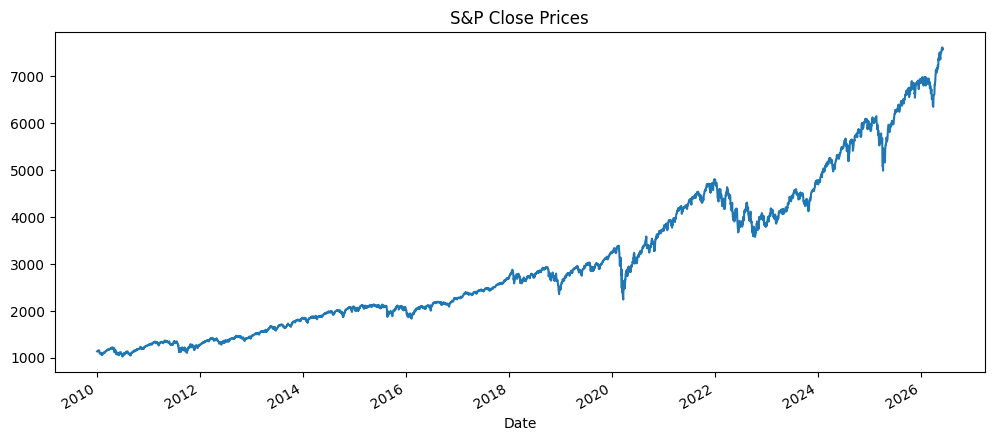

In [24]:
#visualizer
merged_df['spx_close'].plot(figsize=(12,5),title='S&P Close Prices')

<Axes: title={'center': 'VIX Close Prices'}, xlabel='Date'>

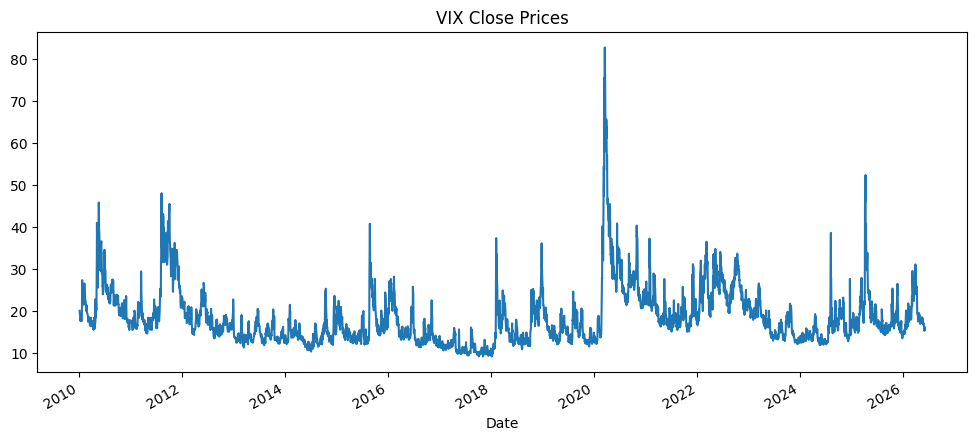

In [25]:
merged_df['vix_close'].plot(figsize=(12,5),title='VIX Close Prices')


Vix - The annualized implied volatility of the S&P index

Volatiliy scales with the root of time.

30 day implied move  = ± VIX/12

1 day implied move = ± VIX/252



In [26]:
import numpy as np

# 1. Daily Log Returns calculation: ln(P_t / P_{t-1})
merged_df['spx_log_ret'] = np.log(merged_df['spx_close'] / merged_df['spx_close'].shift(1))

# 2. 30-day rolling sample standard deviation of log returns
merged_df['spx_roll_std'] = merged_df['spx_log_ret'].rolling(window=30).std()

# 3. Annualize rolling daily volatility using sqrt(252)
merged_df['spx_realized_vol'] = merged_df['spx_roll_std'] * np.sqrt(252)

# Inspect the tail of the new columns
merged_df[['spx_close', 'spx_log_ret', 'spx_roll_std', 'spx_realized_vol']].tail()

,spx_close,spx_log_ret,spx_roll_std,spx_realized_vol
Date,,,,
2026-05-29,7580.060059,0.002170,0.006477,0.102822
2026-06-01,7599.959961,0.002622,0.006224,0.098799
2026-06-02,7609.779785,0.001291,0.006168,0.097908
2026-06-03,7553.680176,-0.007399,0.006220,0.098740
2026-06-04,7584.310059,0.004047,0.006038,0.095845
